In [1]:
import numpy as np
import itertools
import matplotlib.pyplot as plt
import pyoti.sparse as oti
from wdegp.wdegp import wdegp
import utils

/home/sam/anaconda3/envs/pyoti_2/lib/python3.9/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


In [2]:
n_order = 2
n_bases = 2
normalize_data = True
kernel = "SE"
kernel_type = "anisotropic"
n_restarts = 15
swarm_size = 200
np.random.seed(42)

In [3]:
def six_hump_camelback(X, alg=np):
    """
    Six-hump camelback function, a 2D benchmark function with multiple local minima.
    """
    x1 = X[:, 0]
    x2 = X[:, 1]
    return (
        (4 - 2.1 * x1**2 + (x1**4) / 3.0) * x1**2
        + x1 * x2
        + (-4 + 4 * x2**2) * x2**2
    )

In [4]:
def create_training_grid(lb=-1.0, ub=1.0, num_points=4):
    # Uniform 2D grid
    x_vals = np.linspace(lb, ub, num_points)
    y_vals = np.linspace(lb, ub, num_points)
    X = np.array(list(itertools.product(x_vals, y_vals)))

    # Interior and target points
    interior = [5, 6, 9, 10]
    target = [12, 13, 14, 15]

    # Reorder points (swap interior with target)
    X_reordered = X.copy()
    X_reordered[interior], X_reordered[target] = X[target], X[interior]

    # Submodel: derivatives at [12, 13, 14, 15]
    submodel_idx = [target]

    # First and second order derivatives in 2D
    deriv_spec = [[[[1,1]], [[2,1]]], [[[1,2]], [[2,2]]]]
    deriv_specs = [deriv_spec]

    return X_reordered, submodel_idx, deriv_specs, interior, target

X_train, submodel_indices, derivative_specs, interior, target = create_training_grid()
X_train[:5]  # Show first few reordered points

array([[-1.        , -1.        ],
       [-1.        , -0.33333333],
       [-1.        ,  0.33333333],
       [-1.        ,  1.        ],
       [-0.33333333, -1.        ]])

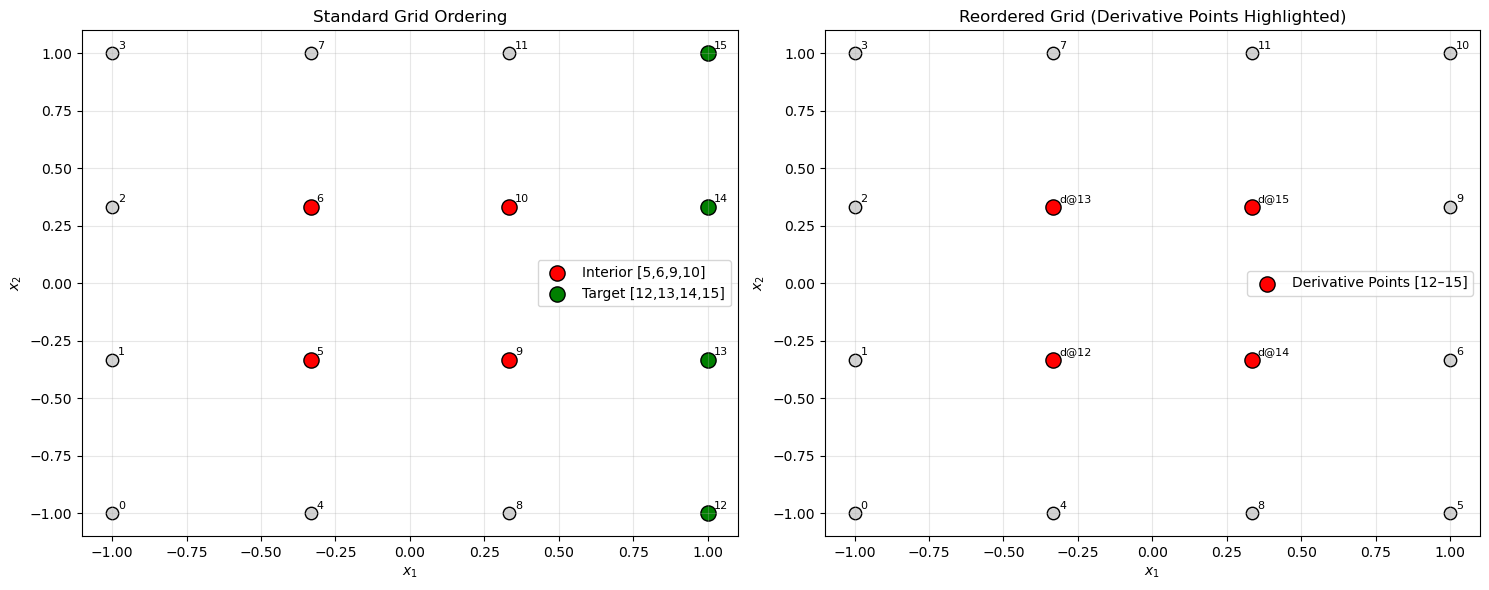

In [5]:
def visualize_reordering(X_train, interior, target, lb=-1.0, ub=1.0, num_points=4):
    x_vals = np.linspace(lb, ub, num_points)
    y_vals = np.linspace(lb, ub, num_points)
    X_standard = np.array(list(itertools.product(x_vals, y_vals)))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Standard grid
    ax1.scatter(X_standard[:,0], X_standard[:,1], c='lightgray', s=80, edgecolor='k')
    ax1.scatter(X_standard[interior,0], X_standard[interior,1],
                c='red', s=120, edgecolor='k', label='Interior [5,6,9,10]')
    ax1.scatter(X_standard[target,0], X_standard[target,1],
                c='green', s=120, edgecolor='k', label='Target [12,13,14,15]')
    for i, p in enumerate(X_standard):
        ax1.text(p[0]+0.02, p[1]+0.02, str(i), fontsize=8)
    ax1.set_title("Standard Grid Ordering")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Reordered grid
    ax2.scatter(X_train[:,0], X_train[:,1], c='lightgray', s=80, edgecolor='k')
    ax2.scatter(X_train[target,0], X_train[target,1],
                c='red', s=120, edgecolor='k', label='Derivative Points [12–15]')
    for i, p in enumerate(X_train):
        label = f"d@{i}" if i in target else str(i)
        ax2.text(p[0]+0.02, p[1]+0.02, label, fontsize=8)
    ax2.set_title("Reordered Grid (Derivative Points Highlighted)")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    for ax in (ax1, ax2):
        ax.set_xlabel("$x_1$")
        ax.set_ylabel("$x_2$")

    plt.tight_layout()
    plt.show()

visualize_reordering(X_train, interior, target)

In [6]:
def prepare_training_data(X_train, submodel_indices, derivative_specs, func, n_order=2):
    y_train_data = []
    y_real = func(X_train, alg=np)

    for k, point_indices in enumerate(submodel_indices):
        X_sub = oti.array(X_train[point_indices])

        # Add OTI tags
        for i in range(2):  # 2D
            for j in range(X_sub.shape[0]):
                X_sub[j, i] += oti.e(i + 1, order=n_order)

        # Evaluate function with hypercomplex perturbations
        y_hc = oti.array([func(x, alg=oti) for x in X_sub])
        y_sub = [y_real]  # base function values

        # Extract derivatives
        for i in range(len(derivative_specs[k])):
            for j in range(len(derivative_specs[k][i])):
                deriv = y_hc.get_deriv(derivative_specs[k][i][j]).reshape(-1,1)
                y_sub.append(deriv)

        y_train_data.append(y_sub)

    return y_train_data

y_train_data = prepare_training_data(X_train, submodel_indices, derivative_specs, six_hump_camelback)
print(f"Submodels: {len(y_train_data)}, Arrays per submodel: {len(y_train_data[0])}")

Submodels: 1, Arrays per submodel: 5


In [7]:
gp_model = wdegp(
    X_train,
    y_train_data,
    n_order,
    n_bases,
    submodel_indices,
    derivative_specs,
    normalize=normalize_data,
    kernel=kernel,
    kernel_type=kernel_type,
)

params = gp_model.optimize_hyperparameters(
     optimizer='jade',
     pop_size = 100,
     n_generations = 15,
     local_opt_every = None,
     debug = True
     )

params

Gen 1: best f=96.3418814766462
Gen 2: best f=92.91060533384288


Gen 3: best f=53.01989686798046


Gen 4: best f=53.01989686798046


Gen 5: best f=53.01989686798046
Gen 6: best f=53.01989686798046


Gen 7: best f=34.74056818410977
Gen 8: best f=34.74056818410977


...

Gen 11: best f=32.799274086927554


Gen 12: best f=15.785616923695887


Gen 13: best f=15.785616923695887
Gen 14: best f=15.785616923695887


Gen 15: best f=15.785616923695887


array([-3.12295871e-01, -5.89212064e-04,  9.86739947e-01, -7.38663182e+00])

In [8]:
def evaluate_gp(gp_model, func, params, lb=-1.0, ub=1.0, N=25):
    x_lin = np.linspace(lb, ub, N)
    y_lin = np.linspace(lb, ub, N)
    X1, X2 = np.meshgrid(x_lin, y_lin)
    X_test = np.column_stack([X1.ravel(), X2.ravel()])

    y_pred, _ = gp_model.predict(X_test, params, calc_cov=False, return_submodels=True)
    y_true = func(X_test, alg=np)
    nrmse = utils.nrmse(y_true, y_pred)

    return X1, X2, y_true.reshape(N,N), y_pred.reshape(N,N), nrmse

X1, X2, y_true_grid, y_pred_grid, nrmse = evaluate_gp(gp_model, six_hump_camelback, params)
print(f"NRMSE: {nrmse:.6f}")

NRMSE: 0.015220


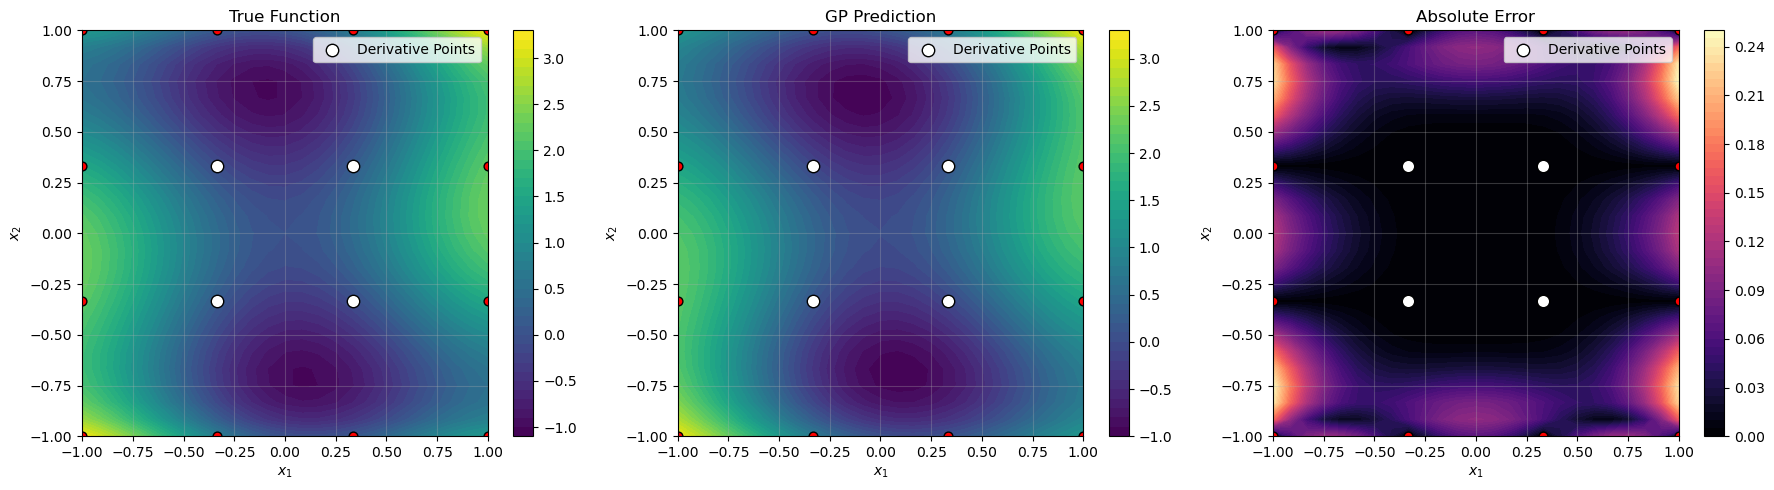

In [9]:
def visualize_results(X1, X2, y_true, y_pred, X_train, target):
    abs_err = np.abs(y_true - y_pred)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    titles = ["True Function", "GP Prediction", "Absolute Error"]
    data = [y_true, y_pred, abs_err]
    cmaps = ["viridis", "viridis", "magma"]

    for ax, Z, title, cmap in zip(axes, data, titles, cmaps):
        c = ax.contourf(X1, X2, Z, levels=50, cmap=cmap)
        fig.colorbar(c, ax=ax)
        ax.scatter(X_train[:,0], X_train[:,1], c='red', edgecolor='k', s=40)
        ax.scatter(X_train[target,0], X_train[target,1],
                   c='white', edgecolor='k', s=80, label="Derivative Points")
        ax.set_title(title)
        ax.set_xlabel("$x_1$")
        ax.set_ylabel("$x_2$")
        ax.legend()
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

visualize_results(X1, X2, y_true_grid, y_pred_grid, X_train, target)